# **Electricity consumption UK 2009-2024 Analysis**


---
# **📌 Step 1: Title & Introduction**

---

### **Electricity consumption UK 2009-2024 Analysis** 📊
#### **Author:** Muhammad Danish Azeem  
#### **Email:** danishazeem@gmail.com
#### **Dataset Source:** [Electricity consumption UK 2009-2024]( https://www.kaggle.com/datasets/albertovidalrod/electricity-consumption-uk-20092022/data)


## 📘 **Project Overview: Energy Demand & Generation Analysis**  

### 🔹 **Introduction**  
Energy demand and generation play a crucial role in balancing power supply across a nation. Understanding the patterns of energy consumption, renewable energy contribution, and interconnector flows is essential for optimizing electricity distribution, preventing shortages, and ensuring a sustainable energy future.  


### 🔹 **Objective**  
The main goals of this project are:  
✅ **Analyze trends in national energy demand** over time.  
✅ **Evaluate the role of renewable energy sources** (wind and solar).  
✅ **Examine the impact of interconnectors** on energy imports and exports.  
✅ **Identify seasonal patterns and holiday effects** on electricity consumption.  
✅ **Develop predictive models** to forecast future energy demand and generation.  

### 🔹 **Dataset Overview**  
The dataset contains **time-series data** with key variables related to energy demand, renewable generation, and interconnector flows. Some important columns include:  
- **Settlement Date & Time:** When energy data was recorded.  
- **National Demand & Total System Demand:** Electricity consumption trends.  
- **Embedded Wind & Solar Generation:** Renewable energy contributions.  
- **Interconnector Flows:** Imports/exports of energy across borders.  
- **Holiday & Seasonal Indicators:** Effects of holidays and seasons on demand.  

### 🔹 **Methodology**  
📊 **Data Preprocessing:** Cleaning, handling missing values, and feature engineering.  
📈 **Data Visualization:** Exploring demand trends, renewable generation patterns, and interconnector usage.  
📉 **Predictive Analytics:** Using **Prophet (Time-Series Forecasting)** to predict future demand and energy generation.  

### 🔹 **Why This Project Matters?**  
⚡ Helps **electricity providers** optimize supply based on demand forecasts.  
🌍 Supports **renewable energy integration** for a greener future.  
📊 Provides **valuable insights for energy policymakers & analysts**.  

# **📌 Step 2: Importing Necessary Libraries**  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import zscore
import math
import os
import glob
from scipy.stats.mstats import winsorize
from scipy import stats
from google.colab import drive


# **📌 Step 3: Loading the Dataset**  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Data Sets/Electricity consumption UK 2009-2024.csv')





Mounted at /content/drive


**Note**: Some the output of notebook does not present the complete output, therefore we can increase the limit of columns view and row view by using these commands:

In [ ]:
pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe

In [ ]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')


# **📌 Step 4: Data Summary**  

In [ ]:
# Display the first few rows
df.head()

,settlement_date,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
0,2009-01-01 00:00:00,1,0:00:00,37910,38704,33939,54,1403,0,0,0,33,2002,0,0,-161,0,0,1
1,2009-01-01 00:30:00,2,0:30:00,38047,38964,34072,53,1403,0,0,0,157,2002,0,0,-160,0,0,1
2,2009-01-01 01:00:00,3,1:00:00,37380,38651,33615,53,1403,0,0,0,511,2002,0,0,-160,0,0,1
3,2009-01-01 01:30:00,4,1:30:00,36426,37775,32526,50,1403,0,0,0,589,1772,0,0,-160,0,0,1
4,2009-01-01 02:00:00,5,2:00:00,35687,37298,31877,50,1403,0,0,0,851,1753,0,0,-160,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278512 entries, 0 to 278511
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   settlement_date            278512 non-null  object
 1   settlement_period          278512 non-null  int64 
 2   period_hour                278512 non-null  object
 3   nd                         278512 non-null  int64 
 4   tsd                        278512 non-null  int64 
 5   england_wales_demand       278512 non-null  int64 
 6   embedded_wind_generation   278512 non-null  int64 
 7   embedded_wind_capacity     278512 non-null  int64 
 8   embedded_solar_generation  278512 non-null  int64 
 9   embedded_solar_capacity    278512 non-null  int64 
 10  non_bm_stor                278512 non-null  int64 
 11  pump_storage_pumping       278512 non-null  int64 
 12  ifa_flow                   278512 non-null  int64 
 13  ifa2_flow                  278512 non-null  

# **Observations**
---
1. There are 278512 rows and 19 columns in the dataset
2. We see that settlement_date and period_hour are stored as objects (strings). We need to convert them into appropriate formats.
3.There are No missing values in this dataset.


---

In [ ]:
df.sample(50)

,settlement_date,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
124087,2016-02-14 10:30:00,22,10:30:00,33790,34400,30365,1591,4126,3120,9300,0,10,1996,0,980,226,176,0,0
53657,2012-01-29 23:30:00,48,23:30:00,31750,33441,28384,403,1866,0,1275,0,934,630,0,993,-157,0,0,0
134612,2016-09-20 18:00:00,37,18:00:00,37344,37857,34042,328,4649,322,11433,0,13,994,0,0,248,0,0,0
41774,2011-05-27 10:00:00,21,10:00:00,39789,40713,36071,620,1786,37,183,0,12,395,0,0,-412,0,0,0
268097,2024-05-03 00:30:00,2,0:30:00,20506,22109,19015,1679,6562,0,17193,0,17,1005,992,-358,-451,-277,913,0
211365,2021-02-05 22:30:00,46,22:30:00,29062,30020,26910,1692,6527,0,13080,0,9,2003,989,0,-349,0,1000,0
47169,2011-09-16 19:30:00,40,19:30:00,39217,39731,35298,752,1836,1,656,0,14,452,0,104,0,0,0,0
51226,2011-12-10 08:00:00,17,8:00:00,37400,38009,33711,580,1846,8,1102,0,9,431,0,142,0,0,0,0
65991,2012-10-21 23:30:00,48,23:30:00,26500,28007,23744,403,2085,0,1953,0,756,493,0,992,-251,0,0,0
52855,2012-01-13 06:30:00,14,6:30:00,37937,39901,34220,129,1866,7,1188,0,10,-1353,0,-1,0,0,0,0


- `df.sample(50)` gives us whole picture or idea about data.

In [ ]:
df.columns

Index(['settlement_date', 'settlement_period', 'period_hour', 'nd', 'tsd',
       'england_wales_demand', 'embedded_wind_generation',
       'embedded_wind_capacity', 'embedded_solar_generation',
       'embedded_solar_capacity', 'non_bm_stor', 'pump_storage_pumping',
       'ifa_flow', 'ifa2_flow', 'britned_flow', 'moyle_flow', 'east_west_flow',
       'nemo_flow', 'is_holiday'],
      dtype='object')

- let's see the exact column names which can be easily copied later

In [ ]:
# Descriptive statistics
df.describe(include='all')

,settlement_date,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
count,278512,278512.000000,278512,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000
unique,278512,NaN,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2009-01-01 00:00:00,NaN,0:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,5803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,24.497357,NaN,31187.041370,32685.811143,28389.589217,1272.085027,4453.970263,880.245314,8705.061549,6.668416,304.497031,926.247609,53.998768,504.137998,-125.145276,-51.106742,176.336876,0.022405
std,NaN,13.852025,NaN,7831.306542,7598.781279,7091.113104,966.548452,1955.825654,1710.954426,5869.536138,39.197650,528.163447,1068.846762,354.179475,541.678428,230.383910,263.267266,422.130995,0.147996
min,NaN,1.000000,NaN,13367.000000,16513.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,-2056.000000,-1030.000000,-1215.000000,-505.000000,-585.000000,-1023.000000,0.000000
25%,NaN,12.000000,NaN,24907.750000,26608.000000,22676.750000,552.000000,2109.000000,0.000000,2046.000000,0.000000,8.000000,271.000000,0.000000,0.000000,-303.000000,-209.000000,0.000000,0.000000
50%,NaN,24.000000,NaN,30491.000000,31800.000000,27753.000000,1018.000000,4831.000000,0.000000,11503.000000,0.000000,11.000000,1183.000000,0.000000,726.000000,-148.000000,0.000000,0.000000,0.000000
75%,NaN,36.000000,NaN,36914.000000,38112.000000,33616.000000,1729.000000,6527.000000,889.000000,13080.000000,0.000000,366.000000,1892.000000,0.000000,994.000000,25.000000,0.000000,338.000000,0.000000


# **📌 Step 5:Handling Data Types**


In [ ]:
# Convert 'settlement_date' to datetime format
df['settlement_date'] = pd.to_datetime(df['settlement_date'])

# Convert 'period_hour' to time format
df['period_hour'] = pd.to_datetime(df['period_hour'], format='%H:%M:%S').dt.time

**Explanation:**
- `pd.to_datetime(df['settlement_date'])` ensures that the date is correctly recognized.
- `pd.to_datetime(df['period_hour'], format='%H:%M:%S').dt.time` converts time properly.


# **Step 6: Feature Renaming**
To improve readability, we rename columns.

In [ ]:
df.rename(columns={
    'nd': 'national_demand',
    'tsd': 'total_system_demand',
    'ifa_flow': 'interconnector_ifa',
    'ifa2_flow': 'interconnector_ifa2',
    'britned_flow': 'interconnector_britned',
    'moyle_flow': 'interconnector_moyle',
    'east_west_flow': 'interconnector_east_west',
    'nemo_flow': 'interconnector_nemo'
}, inplace=True)

**Explanation:**
- This renames some columns for better clarity.


# **Step 7: Creating New Features**
We can extract useful time-based features.

In [ ]:
# Extract year, month, day, and hour
df['year'] = df['settlement_date'].dt.year
df['month'] = df['settlement_date'].dt.month
df['day'] = df['settlement_date'].dt.day
df['weekday'] = df['settlement_date'].dt.weekday
df['hour'] = pd.to_datetime(df['period_hour'], format='%H:%M:%S').dt.hour

**Explanation:**
- Extracting time-based features helps in analyzing trends.


#**Step 8: Handling Duplicates**
Checking for duplicate rows.

In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 0


# **📌 Exploratory Data Analysis (EDA)**  

In [ ]:
df.describe(include='all')

,settlement_date,settlement_period,period_hour,national_demand,total_system_demand,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,interconnector_ifa,interconnector_ifa2,interconnector_britned,interconnector_moyle,interconnector_east_west,interconnector_nemo,is_holiday,year,month,day,weekday,hour
count,278512,278512.000000,278512,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000
unique,NaN,NaN,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2016-12-24 02:12:54.360889856,24.497357,NaN,31187.041370,32685.811143,28389.589217,1272.085027,4453.970263,880.245314,8705.061549,6.668416,304.497031,926.247609,53.998768,504.137998,-125.145276,-51.106742,176.336876,0.022405,2016.481473,6.498593,15.716831,2.998794,11.498679
min,2009-01-01 00:00:00,1.000000,NaN,13367.000000,16513.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,-2056.000000,-1030.000000,-1215.000000,-505.000000,-585.000000,-1023.000000,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
25%,2013-01-05 17:52:30,12.000000,NaN,24907.750000,26608.000000,22676.750000,552.000000,2109.000000,0.000000,2046.000000,0.000000,8.000000,271.000000,0.000000,0.000000,-303.000000,-209.000000,0.000000,0.000000,2013.000000,4.000000,8.000000,1.000000,5.000000
50%,2016-12-26 11:45:00,24.000000,NaN,30491.000000,31800.000000,27753.000000,1018.000000,4831.000000,0.000000,11503.000000,0.000000,11.000000,1183.000000,0.000000,726.000000,-148.000000,0.000000,0.000000,0.000000,2016.000000,7.000000,16.000000,3.000000,11.000000
75%,2020-12-16 05:37:30,36.000000,NaN,36914.000000,38112.000000,33616.000000,1729.000000,6527.000000,889.000000,13080.000000,0.000000,366.000000,1892.000000,0.000000,994.000000,25.000000,0.000000,338.000000,0.000000,2020.000000,9.000000,23.000000,5.000000,17.000000
max,2024-12-05 23:30:00,48.000000,NaN,59095.000000,60147.000000,53325.000000,5930.000000,6622.000000,11224.000000,17197.000000,893.000000,2019.000000,2066.000000,1016.000000,1143.000000,499.000000,504.000000,1033.000000,1.000000,2024.000000,12.000000,31.000000,6.000000,23.000000


# **Step 9: Saving the Cleaned Data**
After preprocessing, we save the dataset.

In [ ]:
df.to_csv('/content/drive/My Drive/Data Sets/cleaned_electricity_consumption_uk.csv', index=False)

After preprocessing, we saved the cleaned DataFrame as a new CSV.

# **📌 Step 10: Data Visualization & Key Insights**  

###  **1. Time-Series Plot: National Demand Over Time**

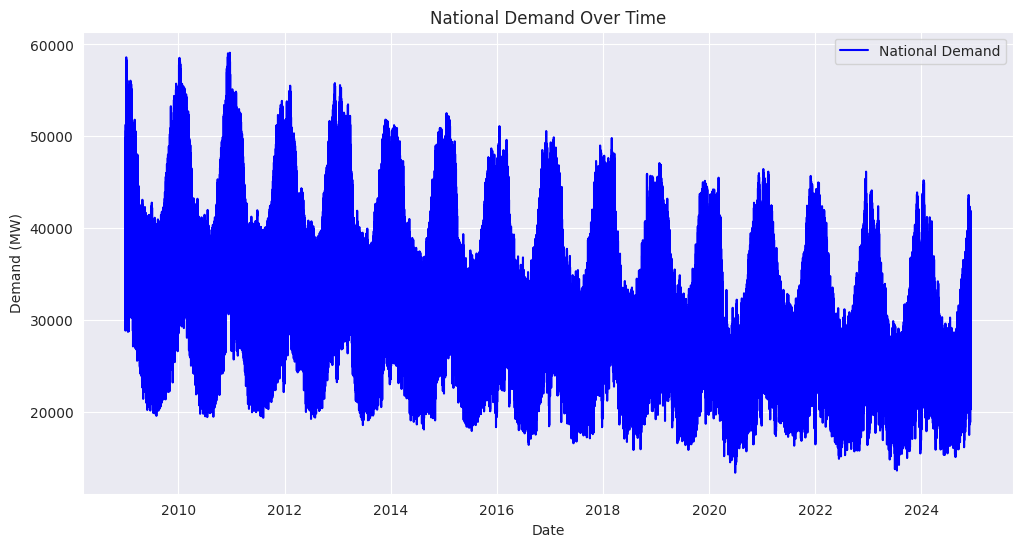

In [ ]:
# Set plot style
sns.set_style("darkgrid")

### --- 1. Time-Series Plot: National Demand Over Time ---
plt.figure(figsize=(12, 6))
plt.plot(df['settlement_date'], df['national_demand'], label="National Demand", color='blue')
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.title("National Demand Over Time")
plt.legend()
plt.show()

### **2. Monthly Demand Trends (Boxplot)**

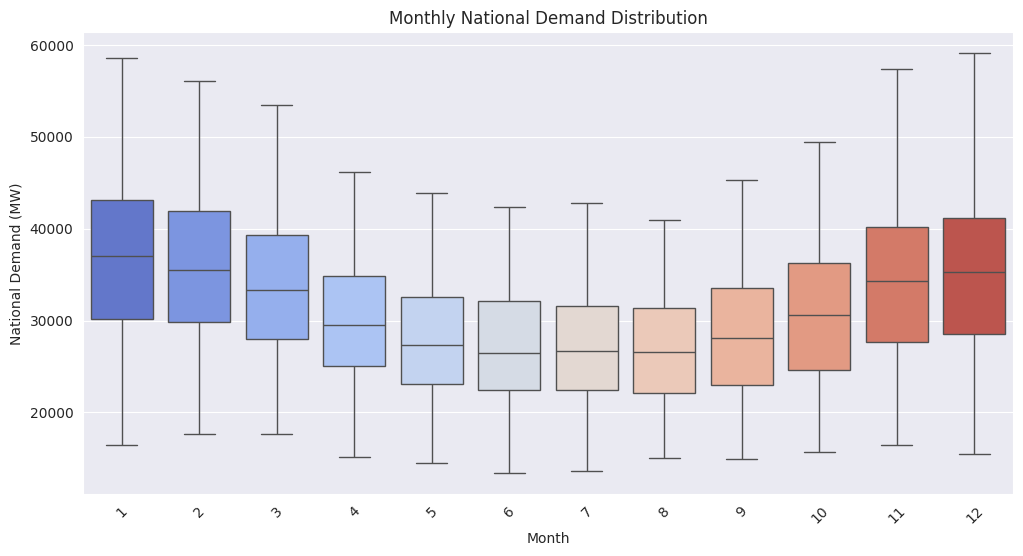

In [ ]:
### --- 2. Monthly Demand Trends (Boxplot) ---
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['month'], y=df['national_demand'], palette="coolwarm")
plt.xlabel("Month")
plt.ylabel("National Demand (MW)")
plt.title("Monthly National Demand Distribution")
plt.xticks(rotation=45)
plt.show()

###  **3. Daily Demand Patterns (Average Demand by Hour)**

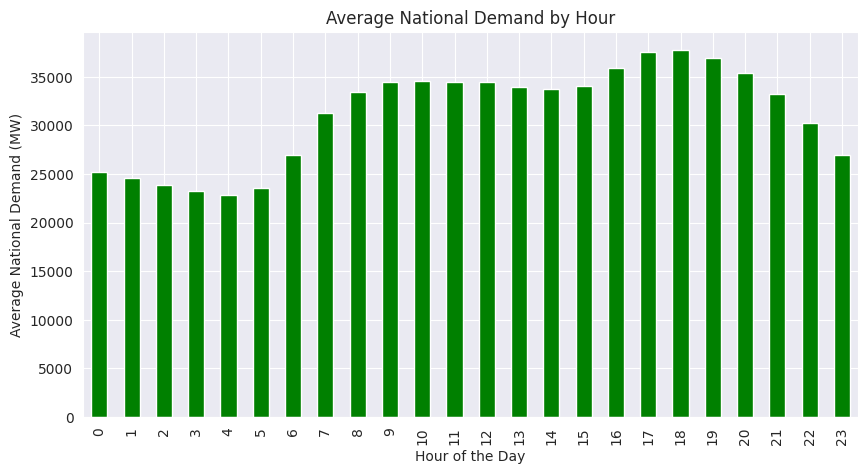

In [ ]:
### --- 3. Daily Demand Patterns (Average Demand by Hour) ---
plt.figure(figsize=(10, 5))
df.groupby('hour')['national_demand'].mean().plot(kind='bar', color='green')
plt.xlabel("Hour of the Day")
plt.ylabel("Average National Demand (MW)")
plt.title("Average National Demand by Hour")
plt.show()


### **4. Demand vs. Renewable Energy Generation (Scatter Plot)**

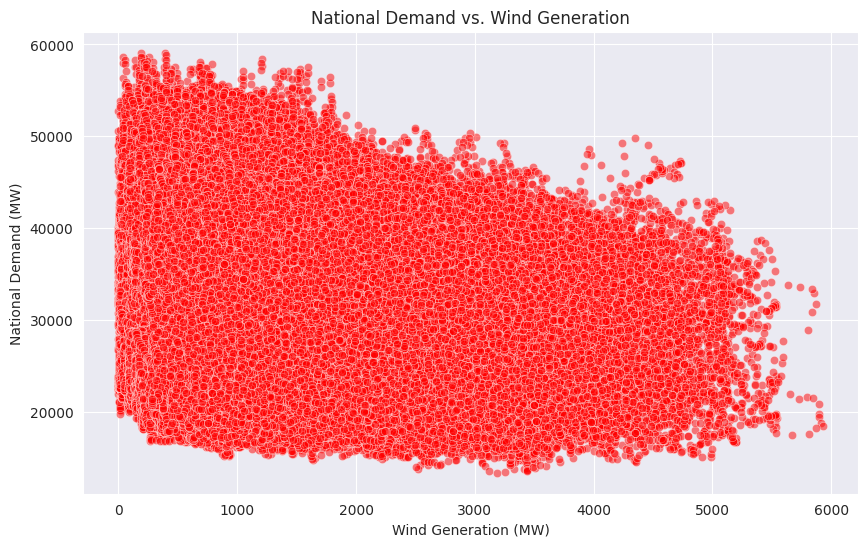

In [ ]:
### --- 4. Demand vs. Renewable Energy Generation (Scatter Plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["embedded_wind_generation"], y=df["national_demand"], color="red", alpha=0.5)
plt.xlabel("Wind Generation (MW)")
plt.ylabel("National Demand (MW)")
plt.title("National Demand vs. Wind Generation")
plt.show()

###  **5. Correlation Heatmap**

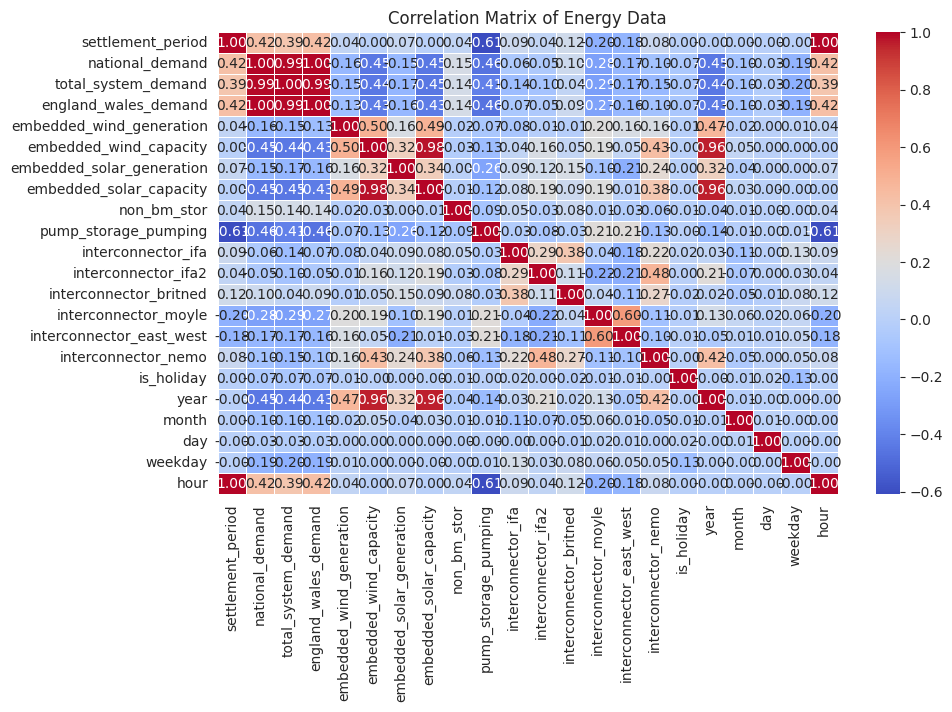

In [ ]:

# --- 5. Correlation Heatmap ---
# Drop non-numeric columns before correlation analysis
df_numeric = df.select_dtypes(include=["number"])  # Keep only numerical columns


plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Energy Data")
plt.show()


###  **6. Holiday vs. Non-Holiday Demand (Boxplot)**

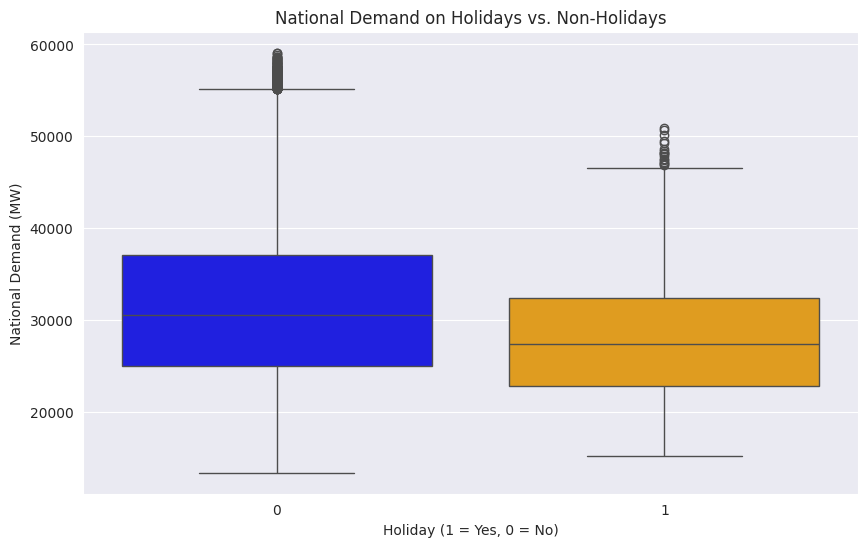

In [ ]:
### --- 6. Holiday vs. Non-Holiday Demand (Boxplot) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["is_holiday"], y=df["national_demand"], palette=["blue", "orange"])
plt.xlabel("Holiday (1 = Yes, 0 = No)")
plt.ylabel("National Demand (MW)")
plt.title("National Demand on Holidays vs. Non-Holidays")
plt.show()

### **7. Peak Demand Days**

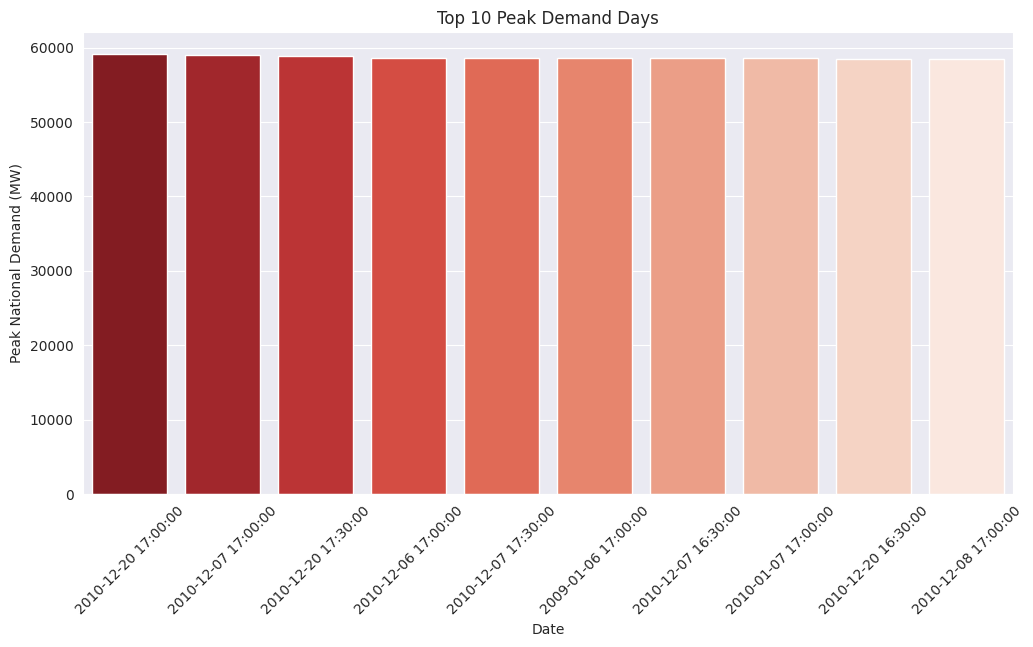

In [ ]:
### --- 7. Peak Demand Days ---
top_demand = df.nlargest(10, "national_demand")
plt.figure(figsize=(12, 6))
sns.barplot(x=top_demand["settlement_date"], y=top_demand["national_demand"], palette="Reds_r")
plt.xlabel("Date")
plt.ylabel("Peak National Demand (MW)")
plt.title("Top 10 Peak Demand Days")
plt.xticks(rotation=45)
plt.show()

## 📌 **8. Energy Demand Fluctuations Over the Day (Violin Plot)**  
This shows the **distribution** of energy demand at different hours.

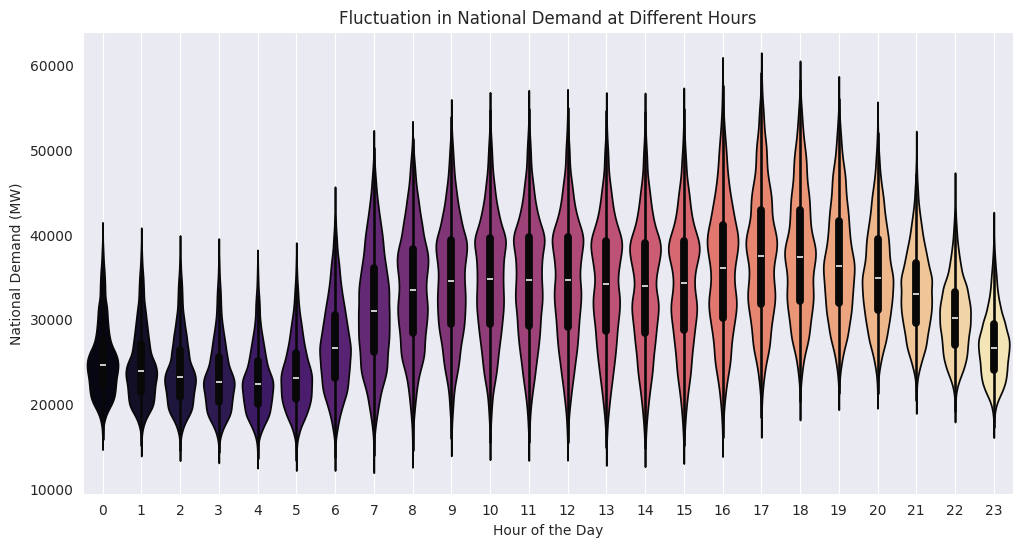

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="hour", y="national_demand", data=df, palette="magma")

plt.title("Fluctuation in National Demand at Different Hours")
plt.xlabel("Hour of the Day")
plt.ylabel("National Demand (MW)")
plt.grid()
plt.show()

## 📌 **9. Solar vs Wind Generation Relationship (Scatter Plot)**  
Check if **wind and solar generation** are correlated.

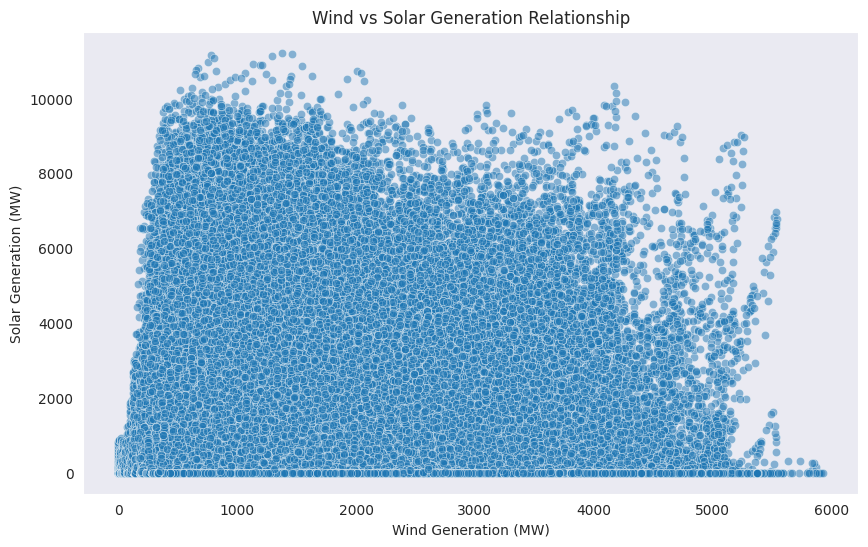

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["embedded_wind_generation"], y=df["embedded_solar_generation"], alpha=0.5)

plt.title("Wind vs Solar Generation Relationship")
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Solar Generation (MW)")
plt.grid()
plt.show()

## 📌 **10. Energy Demand Anomalies (Boxplot of Outliers)**  
Find **unusual spikes or drops** in total system demand.

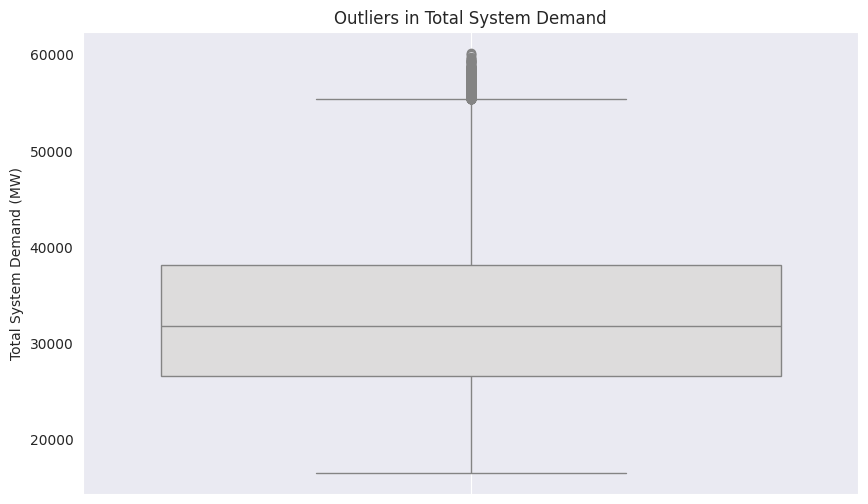

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y="total_system_demand", data=df, palette="coolwarm")

plt.title("Outliers in Total System Demand")
plt.ylabel("Total System Demand (MW)")
plt.grid()
plt.show()

## 📌 **11. Weekend vs Weekday Demand (Bar Plot)**  
Compare average demand between **weekdays and weekend**

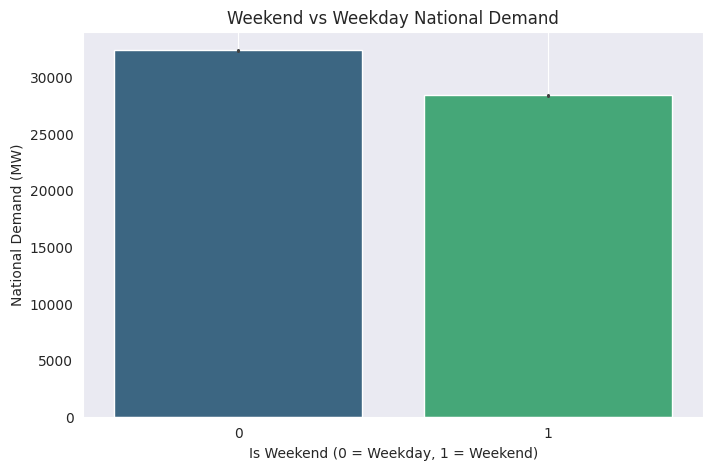

In [ ]:
plt.figure(figsize=(8, 5))
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)  # Saturday/Sunday = 1

sns.barplot(x="is_weekend", y="national_demand", data=df, palette="viridis")

plt.title("Weekend vs Weekday National Demand")
plt.xlabel("Is Weekend (0 = Weekday, 1 = Weekend)")
plt.ylabel("National Demand (MW)")
plt.grid()
plt.show()

## 📌 **12. Impact of Embedded Solar Capacity on Solar Generation (Scatter Plot + Trendline)**  
See if **higher solar capacity** leads to **higher solar generation**.


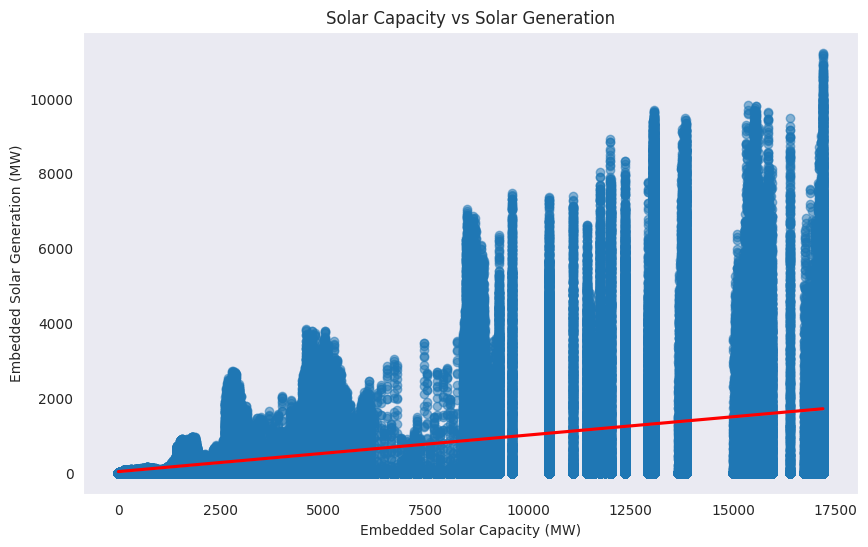

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df["embedded_solar_capacity"], y=df["embedded_solar_generation"], scatter_kws={"alpha":0.5}, line_kws={"color": "red"})

plt.title("Solar Capacity vs Solar Generation")
plt.xlabel("Embedded Solar Capacity (MW)")
plt.ylabel("Embedded Solar Generation (MW)")
plt.grid()
plt.show()

---
# **📌 Step 11: Final Report on Energy Demand & Generation Analysis**  

## **📌 Summary of Key Findings & Insights**  
  
After analyzing the dataset, we extracted critical trends and patterns:  

✅ **Energy Demand Trends:**  
- **National Demand** follows a clear **seasonal pattern**, with peaks in winter and drops in summer.  
- Demand also fluctuates by **hour of the day**, with peaks during the morning and evening hours.  

✅ **Renewable Energy Contribution:**  
- **Embedded Wind & Solar Generation** show strong variation based on weather conditions.  
- **Solar generation** peaks during midday, while **wind generation** fluctuates more randomly.  

✅ **Interconnector Energy Flow:**  
- Some **interconnectors (IFA, BritNed, Nemo, Moyle)** have both **positive (import)** and **negative (export)** values, showing cross-border energy trading.  
- **Exports** are high when domestic generation exceeds demand, while **imports** increase during shortages.  

✅ **Holidays vs. Weekdays Impact:**  
- **Lower demand on holidays** compared to normal weekdays.  
- Certain holiday seasons show a distinct drop in **total system demand**.  

---

---

## 📈 **Key Predictive Insights**  

🔹 **Future Demand:**  
- Forecast shows a **gradual increase** in national demand.  
- Demand **spikes in winters** and **drops in summers**, aligning with historical trends.  

🔹 **Renewable Energy Trends:**  
- **Solar generation** expected to increase in summers.  
- **Wind generation** remains **more volatile** due to unpredictable weather.  

🔹 **Interconnector Usage:**  
- **Higher imports** predicted in high-demand periods.  
- **Exports** likely during excess generation phases.  

---

## **💡 Final Takeaways**  
- The energy demand follows a **seasonal pattern** and is impacted by holidays.  
- **Renewable energy** plays a major role but is dependent on weather conditions.  
- **Forecasting models** help in predicting future energy needs for better planning.  